# NLA vs TATT IA Model Comparison

Compare posterior mode + MAP + errors for NLA vs TATT across different configurations:
- TATT [0.3, 3] h$^{-1}$Mpc (fiducial)
- NLA [0.3, 3] h$^{-1}$Mpc
- TATT [1, 5] h$^{-1}$Mpc
- TATT No Bin 3
- TATT No Bin 4

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import importlib
import cmocean.cm as cmo

from pathlib import Path

import src.analysis.plots as plots
import src.statistics.corrfiles as cf
import corner_utils as corners

cmap = cmo.dense
PAPER_FIGURES_ROOT = Path(
    "/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/"
)
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)
CHAIN_ROOT = cf.get_base_dir() / "cosmic_shear" / "chains"
default_file = "hsc-y3-shear.txt"

In [ ]:
# ---------- chain files ----------
chain_paths = {
    r"TATT $[0.3,\,3]$h$^{-1}$Mpc": CHAIN_ROOT / "out-corrected-nz-real-0.3-3-fiducial" / default_file,
    r"NLA $[0.3,\,3]$h$^{-1}$Mpc": CHAIN_ROOT / "out-corrected-nz-real-0.3-3-nla" / default_file,
    r"No Bin 3": CHAIN_ROOT / "out-corrected-nz-real-0.3-3-no_z3" / default_file,
    r"No Bin 4": CHAIN_ROOT / "out-corrected-nz-real-0.3-3-no_z4" / default_file,
}

# pop_params for runs that exclude a bin
pop_params_map = {
    r"No Bin 3": "wl_photoz_errors--bias_3",
    r"No Bin 4": "wl_photoz_errors--bias_4",
}

params = [
    "COSMOLOGICAL_PARAMETERS--S_8",
    "cosmological_parameters--omega_m",
    "wl_photoz_errors--bias_3",
    "wl_photoz_errors--bias_4",
]
param_labels_map = {
    "COSMOLOGICAL_PARAMETERS--S_8": r"$S_8$",
    "cosmological_parameters--omega_m": r"$\Omega_m$",
    "wl_photoz_errors--bias_3": r"$\Delta z_3$",
    "wl_photoz_errors--bias_4": r"$\Delta z_4$",
}
# internal labels list (used by getdist)
internal_param_labels = [r"S_8", r"\Omega_m", r"\Delta z_3", r"\Delta z_4"]

base_burn = 0.1

In [ ]:
importlib.reload(corners)

samples_dict = {}   
ndf_dict = {} 

for label, fpath in chain_paths.items():
    pop = pop_params_map.get(label, None)
    df, header, prior_rescale = corners.load_and_process_data(fpath, pop_params=pop)
    assert np.allclose(prior_rescale, 1.0), f"Prior rescale != 1 for {label}"

    samples, ndf, w = corners.make_mc_sample(
        df,
        params,
        internal_param_labels,
        prior_rescale,
        label,
        burn=base_burn,
        use_log_weight=True,
    )
    samples_dict[label] = samples
    ndf_dict[label] = ndf

chain_labels = list(chain_paths.keys())
print(f"Loaded {len(chain_labels)} chains: {chain_labels}")

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Loaded 4 chains: ['TATT $[0.3,\\,3]$h$^{-1}$Mpc', 'NLA $[0.3,\\,3]$h$^{-1}$Mpc', 'No Bin 3', 'No Bin 4']


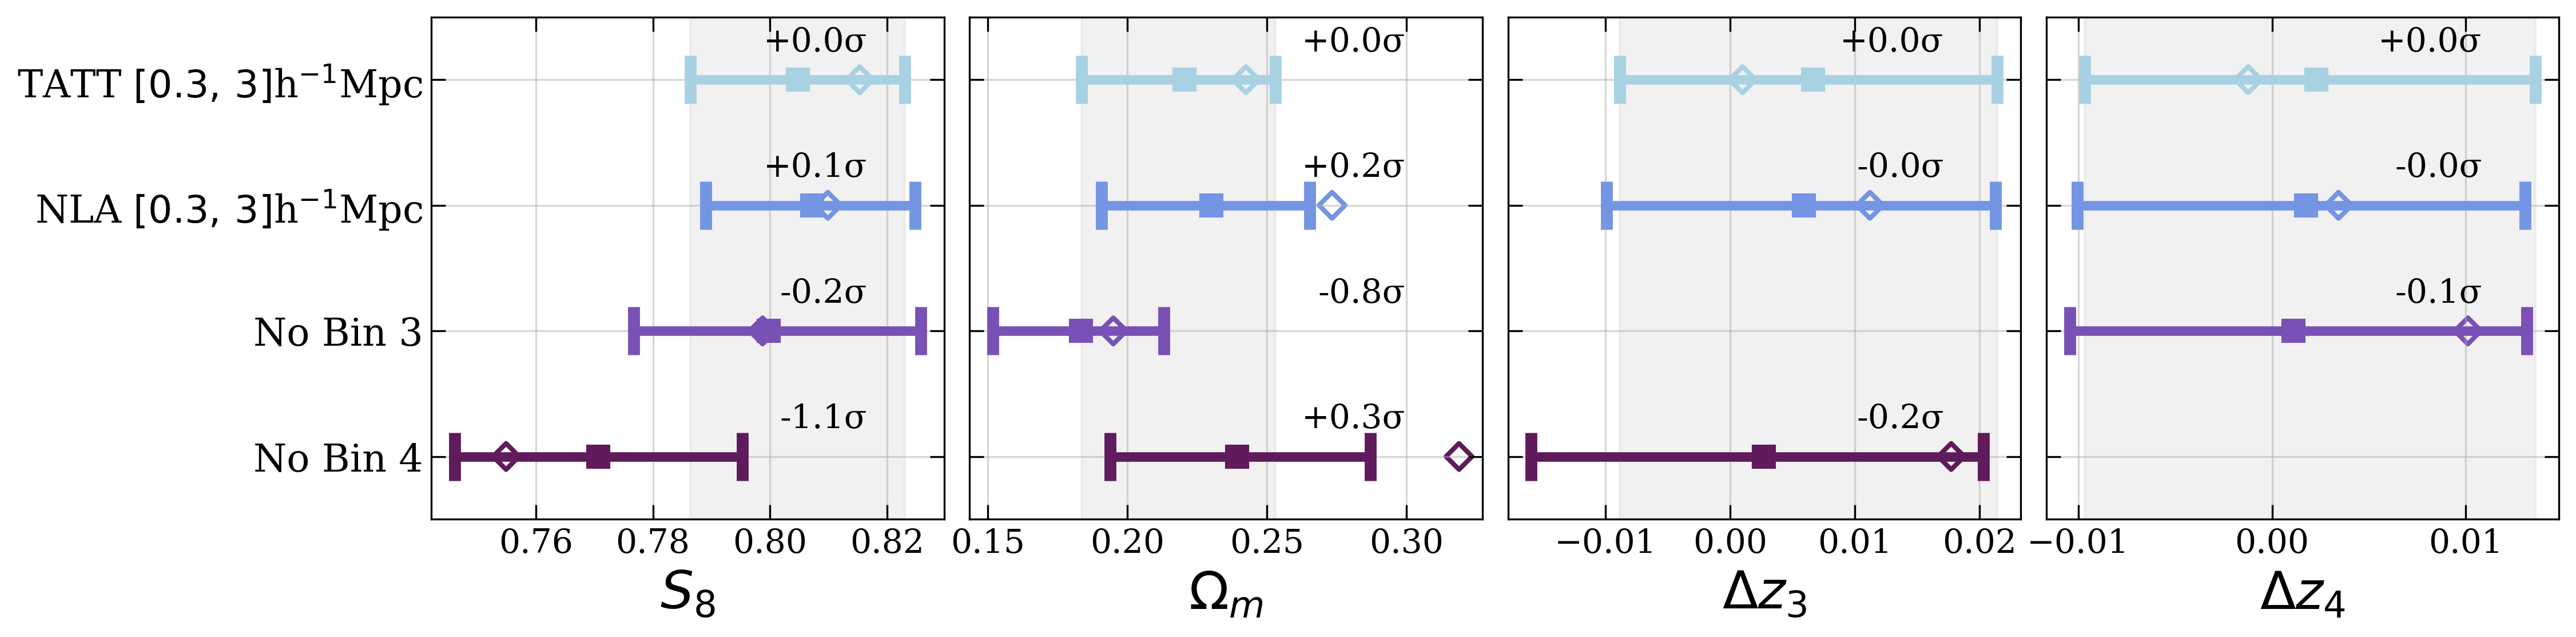

In [ ]:
importlib.reload(corners)
plots.plot_settings()

n_params = len(params)
n_chains = len(chain_labels)
colors = cmap(np.linspace(0.15, 0.85, n_chains))

# reference chain = TATT fiducial [0.3, 3]
ref_label = r"TATT $[0.3,\,3]$h$^{-1}$Mpc"

total_rows = n_chains

with pm.make_plot(
    "ia_comparison",
    figsize=(4 * n_params, total_rows * 0.7 + 1),
    nrows=1,
    ncols=n_params,
    sharey=True,
    show=True,
    tight_layout=False,
) as (fig, axes):

    plt.subplots_adjust(wspace=0.05)
    if n_params == 1:
        axes = [axes]

    for i, param in enumerate(params):
        ax = axes[i]

        # reference values
        ref_samples = samples_dict[ref_label]
        ref_ndf = ndf_dict[ref_label]
        if param not in ref_samples.paramNames.list():
            continue
        ref_map, ref_mode, ref_mean, ref_ci68, ref_ci95 = corners.analyze_param(
            ref_ndf, ref_samples, param
        )
        ref_l68, ref_u68 = ref_ci68
        ref_err = 0.5 * (ref_u68 - ref_l68)

        # shaded reference band
        ax.axvspan(ref_l68, ref_u68, color="lightgray", alpha=0.3)

        for j, label in enumerate(reversed(chain_labels)):
            samples = samples_dict[label]
            ndf = ndf_dict[label]
            color = colors[n_chains - 1 - j]
            ypos = j

            if param not in samples.paramNames.list():
                continue

            map_val, mode, mean, ci68, ci95 = corners.analyze_param(
                ndf, samples, param
            )
            l68, u68 = ci68
            err = 0.5 * (u68 - l68)

            sigma = corners.compute_sigma_analytic(
                val1=mode, sig1=err, val2=ref_mode, sig2=ref_err
            )

            # mode + asymmetric error bar
            ax.errorbar(
                mode,
                ypos,
                xerr=[[mode - l68], [u68 - mode]],
                fmt="s",
                color=color,
                ecolor=color,
                elinewidth=4,
                capsize=10,
                capthick=5,
                markersize=9,
            )
            # MAP as open diamond
            ax.scatter(
                map_val,
                ypos,
                marker="D",
                facecolors="none",
                edgecolors=color,
                linewidths=2,
                s=60,
            )
            # sigma annotation
            ax.text(
                0.85,
                ypos + 0.3,
                f"{sigma:+.1f}\u03c3",
                transform=ax.get_yaxis_transform(),
                ha="right",
                va="center",
                fontsize=14,
            )

        ax.set_ylim(-0.5, n_chains - 0.5)
        ax.grid(True, alpha=0.5, axis="x")
        ax.set_xlabel(param_labels_map.get(param, param), fontsize=22)
        ax.tick_params(axis="x", labelsize=14)

        if i == 0:
            ax.set_yticks(range(n_chains))
            ax.set_yticklabels(list(reversed(chain_labels)), fontsize=16)

In [ ]:
importlib.reload(corners)

out_summary = Path("summaries/summary_ia_comparison.txt")
out_summary.parent.mkdir(exist_ok=True)
if out_summary.exists():
    out_summary.unlink()

with open(out_summary, "w") as f:
    for label in chain_labels:
        samples = samples_dict[label]
        ndf = ndf_dict[label]
        f.write(f"\n=== {label} ===\n")
        print(f"\n=== {label} ===")
        for param in params:
            if param not in samples.paramNames.list():
                continue
            map_val, mode, mean, ci68, ci95 = corners.analyze_param(ndf, samples, param)
            l68, u68 = ci68
            upper_err = u68 - mode
            lower_err = mode - l68
            latex = f"${mode:.3f}^{{+{upper_err:.3f}}}_{{-{lower_err:.3f}}}\\;({map_val:.3f})$"
            plabel = param_labels_map.get(param, param)
            line = f"{plabel:20s}  {latex}"
            print(line)
            f.write(line + "\n")

print(f"\nSummary saved to {out_summary}")


=== TATT $[0.3,\,3]$h$^{-1}$Mpc ===
$S_8$                 $0.805^{+0.018}_{-0.018}\;(0.815)$
$\Omega_m$            $0.221^{+0.033}_{-0.037}\;(0.243)$
$\Delta z_3$          $0.007^{+0.015}_{-0.016}\;(0.001)$
$\Delta z_4$          $0.002^{+0.011}_{-0.012}\;(-0.001)$

=== NLA $[0.3,\,3]$h$^{-1}$Mpc ===
$S_8$                 $0.807^{+0.018}_{-0.018}\;(0.810)$
$\Omega_m$            $0.230^{+0.035}_{-0.039}\;(0.273)$
$\Delta z_3$          $0.006^{+0.015}_{-0.016}\;(0.011)$
$\Delta z_4$          $0.002^{+0.011}_{-0.012}\;(0.003)$

=== No Bin 3 ===
$S_8$                 $0.800^{+0.026}_{-0.023}\;(0.799)$
$\Omega_m$            $0.183^{+0.030}_{-0.031}\;(0.195)$
$\Delta z_4$          $0.001^{+0.012}_{-0.012}\;(0.010)$

=== No Bin 4 ===
$S_8$                 $0.771^{+0.025}_{-0.025}\;(0.755)$
$\Omega_m$            $0.239^{+0.048}_{-0.046}\;(0.319)$
$\Delta z_3$          $0.003^{+0.018}_{-0.019}\;(0.018)$

Summary saved to summaries/summary_ia_comparison.txt
